# سه تعریف حباب Zinc و روش اصلی درون‌یابی

تمام نمودارها در حافظه و داخل notebook نمایش داده می‌شوند؛ این notebook هیچ تصویر یا CSV جدیدی ذخیره نمی‌کند. benchmark فیزیکی، میانگین موزون حجمی معاملات مثبت شمش‌های 99.97 و 99.98 در قراردادهای نقدی و نقدی مچینگ است.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_project() -> Path:
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        if (base / 'data/processed/zinc_certificate_bubble.csv').exists():
            return base
        candidate = base / 'commodity/zinc'
        if (candidate / 'data/processed/zinc_certificate_bubble.csv').exists():
            return candidate
    raise FileNotFoundError('Could not locate commodity/zinc')

PROJECT = find_project()
P = PROJECT / 'data/processed'
benchmark = pd.read_csv(P / 'zinc_9798_cash_daily.csv')
physical_direct = pd.read_csv(P / 'physical_vs_intrinsic_bubble.csv', parse_dates=['date'])
certificate_direct = pd.read_csv(P / 'certificate_vs_intrinsic_bubble.csv', parse_dates=['date'])
primary = pd.read_csv(P / 'zinc_certificate_bubble.csv', parse_dates=['date'])
regression = pd.read_csv(P / 'intrinsic_regression.csv', parse_dates=['date'])
regression_metrics = pd.read_csv(P / 'intrinsic_regression_metrics.csv')
print(PROJECT)

C:\Work\commodity\zinc


## خلاصه داده و سه تعریف حباب

In [2]:
def describe_bubble(frame, column, label):
    values = frame[column]
    return {
        'definition': label, 'rows': len(frame),
        'first_date': frame['date'].min().date(), 'last_date': frame['date'].max().date(),
        'mean_pct': values.mean(), 'median_pct': values.median(),
        'min_pct': values.min(), 'max_pct': values.max(),
        'positive_days': values.gt(0).sum(), 'negative_days': values.lt(0).sum(),
    }

summary = pd.DataFrame([
    describe_bubble(physical_direct, 'physical_vs_intrinsic_bubble_pct', 'physical / intrinsic'),
    describe_bubble(certificate_direct, 'certificate_vs_intrinsic_bubble_pct', 'certificate / intrinsic'),
    describe_bubble(primary, 'certificate_bubble_pct', 'certificate / estimated physical (primary)'),
])
display(summary.style.format({c: '{:,.2f}' for c in ['mean_pct','median_pct','min_pct','max_pct']}))
display(pd.DataFrame({
    'metric': ['benchmark days','certificate days','exact anchors','interpolated primary days'],
    'value': [len(benchmark), len(certificate_direct), primary['physical_ratio_method'].eq('observed').sum(), primary['physical_ratio_method'].eq('linear_interpolation').sum()]
}))

,definition,rows,first_date,last_date,mean_pct,median_pct,min_pct,max_pct,positive_days,negative_days
0,physical / intrinsic,554,2009-08-16,2026-08-09,-13.14,-15.87,-36.02,22.28,75,479
1,certificate / intrinsic,182,2025-10-20,2026-08-09,-20.13,-18.58,-33.91,-10.54,0,182
2,certificate / estimated physical (primary),178,2025-10-26,2026-08-09,0.34,1.02,-19.58,16.97,102,76


,metric,value
0,benchmark days,554
1,certificate days,182
2,exact anchors,41
3,interpolated primary days,137


## نمودار شماتیک سه حباب

دو نمودار مستقیم فاصله هر بازار با LME×دلار را نشان می‌دهند. نمودار سوم معیار اصلی است: فاصله گواهی با قیمت فیزیکی داخلی برآوردشده.

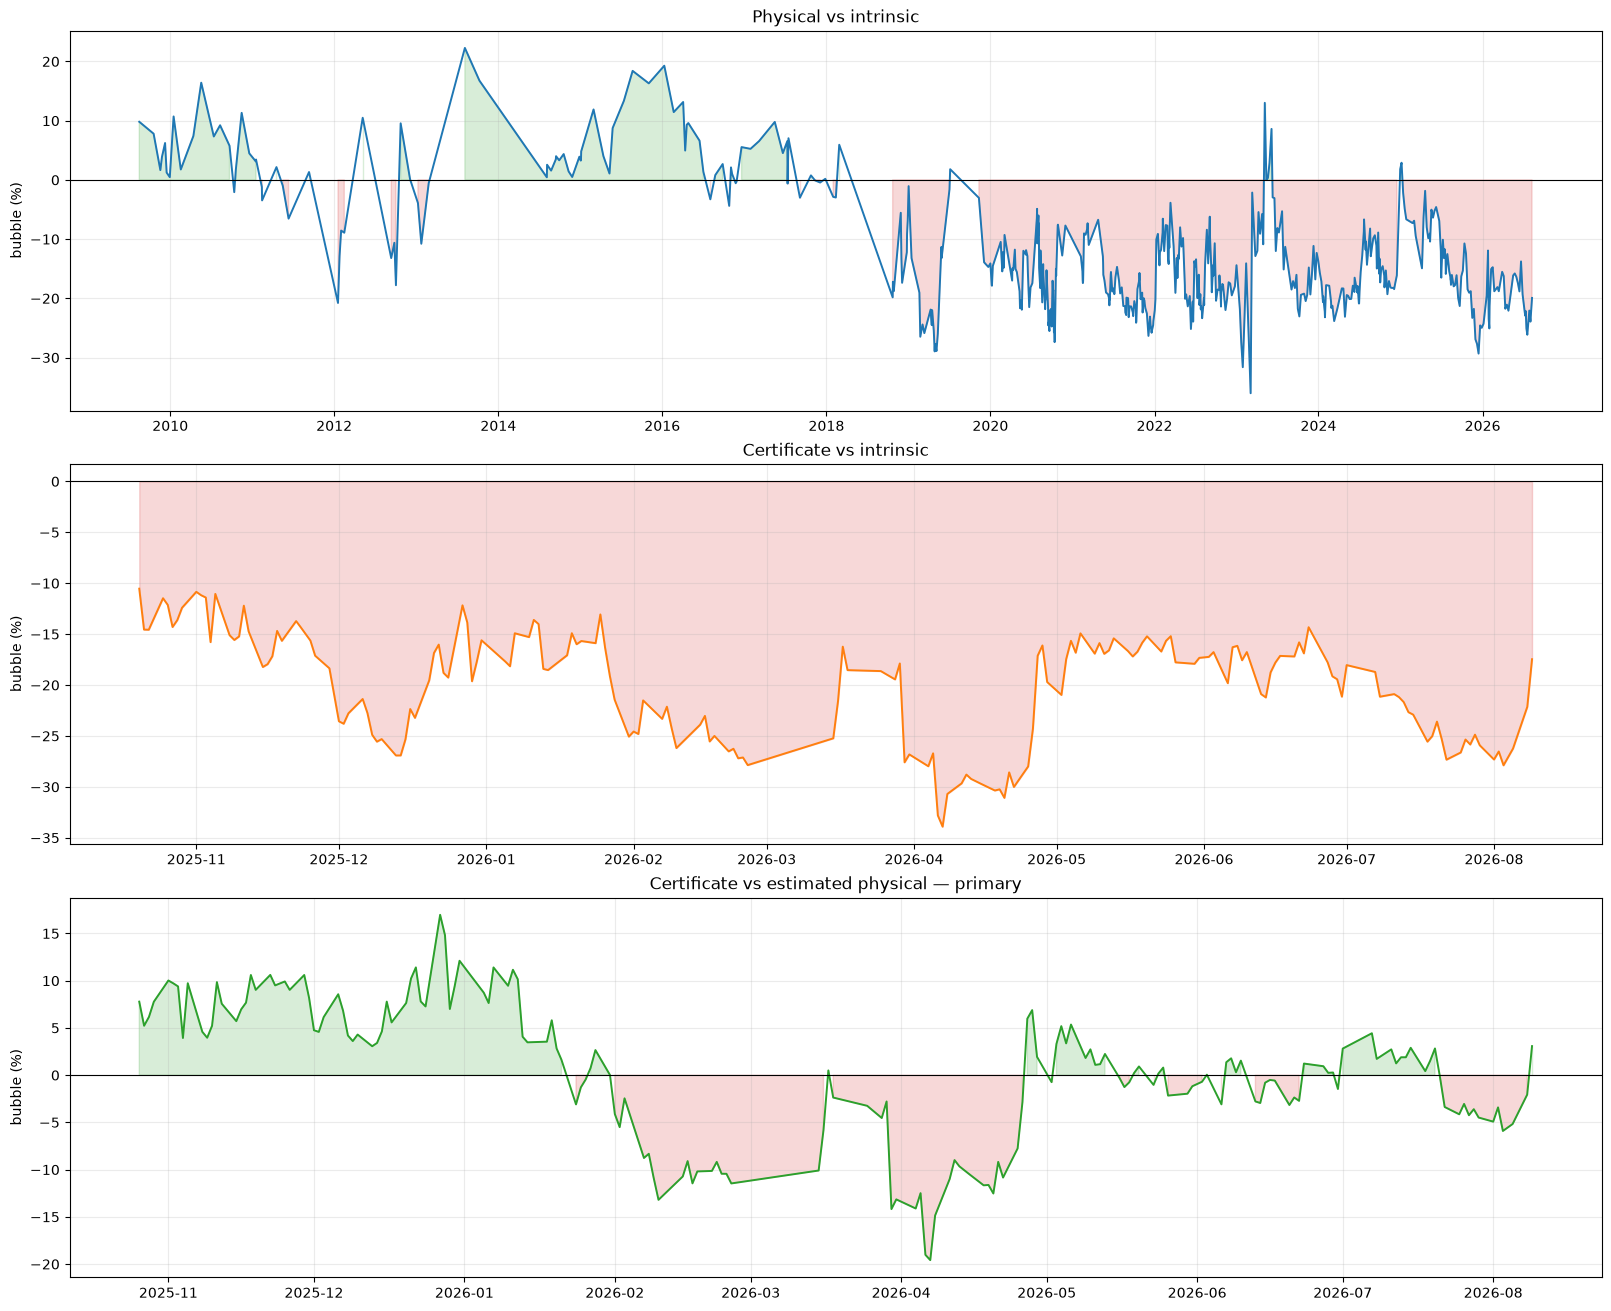

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=False, constrained_layout=True)
series = [
    (physical_direct, 'physical_vs_intrinsic_bubble_pct', 'Physical vs intrinsic', 'tab:blue'),
    (certificate_direct, 'certificate_vs_intrinsic_bubble_pct', 'Certificate vs intrinsic', 'tab:orange'),
    (primary, 'certificate_bubble_pct', 'Certificate vs estimated physical — primary', 'tab:green'),
]
for ax, (frame, column, title, color) in zip(axes, series):
    ax.plot(frame['date'], frame[column], color=color, linewidth=1.4)
    ax.fill_between(frame['date'], 0, frame[column], where=frame[column].ge(0), color='tab:green', alpha=.18)
    ax.fill_between(frame['date'], 0, frame[column], where=frame[column].lt(0), color='tab:red', alpha=.18)
    ax.axhline(0, color='black', linewidth=.8)
    ax.set_title(title); ax.set_ylabel('bubble (%)'); ax.grid(alpha=.25)
plt.show()

## اجزای قیمت ذاتی و benchmark فیزیکی

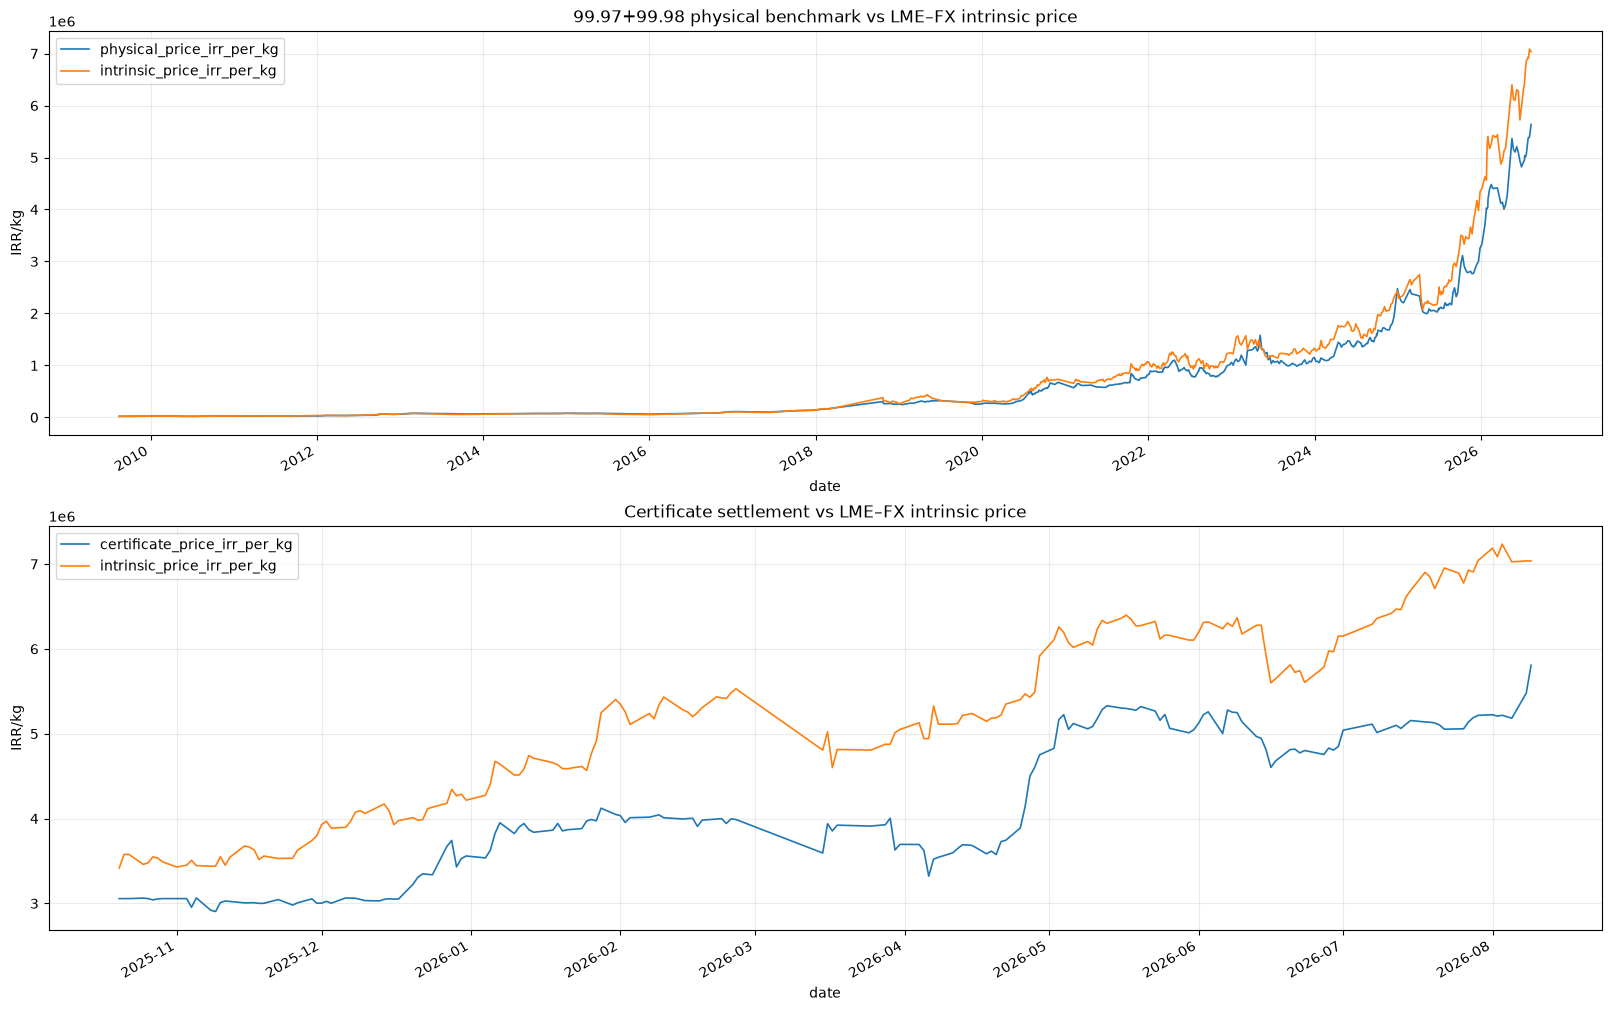

,physical_trade_date_jalali,grades,grade_99_97_quantity,grade_99_98_quantity,total_quantity,grade_99_97_weighted_price,grade_99_98_weighted_price,physical_weighted_price
524,1404/11/06,99.97,100,0,100,4.007416e+06,NaN,4.007416e+06
525,1404/11/08,99.97|99.98,100,25,125,4.007416e+06,4.048308e+06,4.015594e+06
526,1404/11/11,99.98,0,50,50,NaN,4.048308e+06,4.048308e+06
527,1404/11/12,99.97|99.98,725,390,1115,4.192483e+06,4.235264e+06,4.207447e+06
528,1404/11/19,99.97|99.98,225,175,400,4.376529e+06,4.421188e+06,4.396067e+06
529,1404/11/26,99.97|99.98,100,175,275,4.441270e+06,4.503110e+06,4.480623e+06
530,1404/12/03,99.97|99.98,150,275,425,4.381454e+06,4.415933e+06,4.403764e+06
531,1404/12/17,99.97|99.98,75,150,225,4.381454e+06,4.426163e+06,4.411260e+06
532,1404/12/23,99.97|99.98,25,100,125,4.381454e+06,4.426163e+06,4.417221e+06
533,1405/01/09,99.97,50,0,50,4.118773e+06,NaN,4.118773e+06


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)
physical_direct.plot(x='date', y=['physical_price_irr_per_kg','intrinsic_price_irr_per_kg'], ax=axes[0], linewidth=1.2)
axes[0].set_title('99.97+99.98 physical benchmark vs LME–FX intrinsic price')
axes[0].set_ylabel('IRR/kg'); axes[0].grid(alpha=.25)
certificate_direct.plot(x='date', y=['certificate_price_irr_per_kg','intrinsic_price_irr_per_kg'], ax=axes[1], linewidth=1.2)
axes[1].set_title('Certificate settlement vs LME–FX intrinsic price')
axes[1].set_ylabel('IRR/kg'); axes[1].grid(alpha=.25)
plt.show()

display(benchmark[['physical_trade_date_jalali','grades','grade_99_97_quantity','grade_99_98_quantity','total_quantity','grade_99_97_weighted_price','grade_99_98_weighted_price','physical_weighted_price']].tail(30))

## شمای anchorها و درون‌یابی روش اصلی

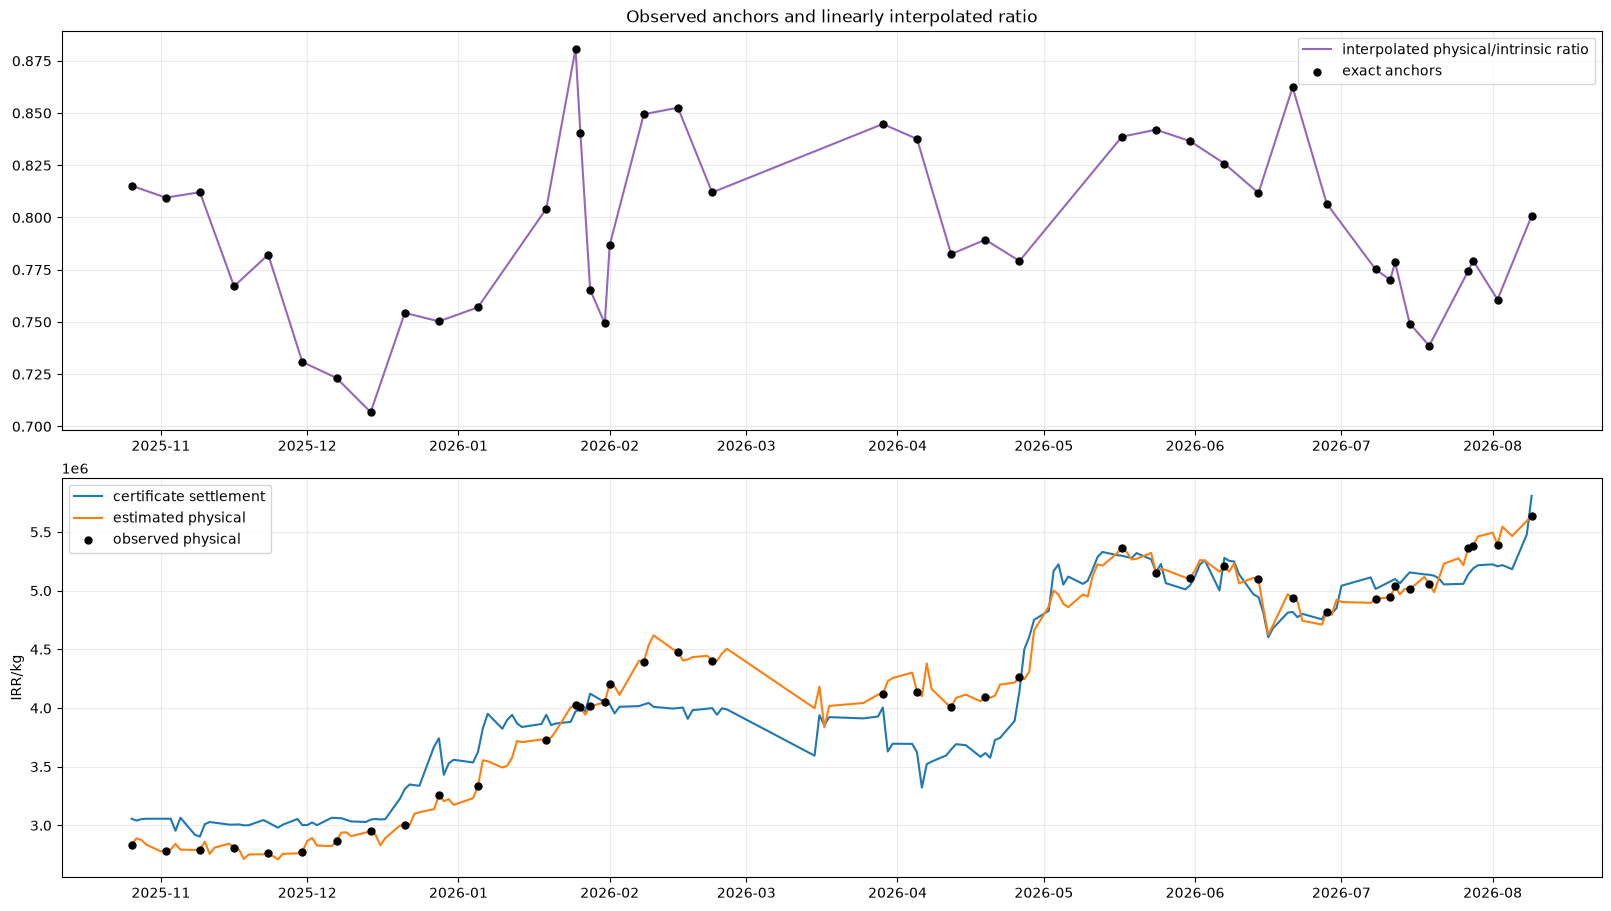

,date,certificate_price_irr_per_kg,observed_physical_price_irr_per_kg,intrinsic_price_irr_per_kg,certificate_bubble_pct
0,2025-10-26,3056519,2.835858e+06,3478706.00,7.781100
5,2025-11-02,3056501,2.785596e+06,3441035.00,9.725210
10,2025-11-09,2904594,2.793914e+06,3440415.00,3.961453
15,2025-11-16,3006513,2.810795e+06,3664316.25,6.963098
20,2025-11-23,3024196,2.761754e+06,3530708.00,9.502712
24,2025-11-30,3002288,2.775485e+06,3797771.25,8.171634
29,2025-12-07,3062958,2.867416e+06,3964993.20,6.819436
34,2025-12-14,3048531,2.948016e+06,4170995.10,3.409581
39,2025-12-21,3309535,3.002456e+06,3980272.00,10.227579
44,2025-12-28,3741989,3.259074e+06,4343878.10,14.817552


In [5]:
observed = primary['physical_ratio_method'].eq('observed')
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
axes[0].plot(primary['date'], primary['physical_ratio'], color='tab:purple', label='interpolated physical/intrinsic ratio')
axes[0].scatter(primary.loc[observed,'date'], primary.loc[observed,'physical_ratio'], color='black', s=25, label='exact anchors', zorder=3)
axes[0].set_title('Observed anchors and linearly interpolated ratio')
axes[0].legend(); axes[0].grid(alpha=.25)
axes[1].plot(primary['date'], primary['certificate_price_irr_per_kg'], label='certificate settlement')
axes[1].plot(primary['date'], primary['estimated_physical_price_irr_per_kg'], label='estimated physical')
axes[1].scatter(primary.loc[observed,'date'], primary.loc[observed,'observed_physical_price_irr_per_kg'], color='black', s=25, label='observed physical', zorder=3)
axes[1].set_ylabel('IRR/kg'); axes[1].legend(); axes[1].grid(alpha=.25)
plt.show()
display(primary.loc[observed, ['date','certificate_price_irr_per_kg','observed_physical_price_irr_per_kg','intrinsic_price_irr_per_kg','certificate_bubble_pct']])

## روش آزمایشی رگرسیون و کنترل سن داده

رگرسیون جایگزین روش اصلی نیست. انتخاب مدل فقط با TimeSeriesSplit و کمترین RMSE خارج‌نمونه انجام شده است.

,model,timeseries_cv_rmse,selected
0,proportional_no_intercept,256696.521571,1
1,linear_with_intercept,341890.957487,0
2,polynomial_degree_2_ridge,468075.148936,0


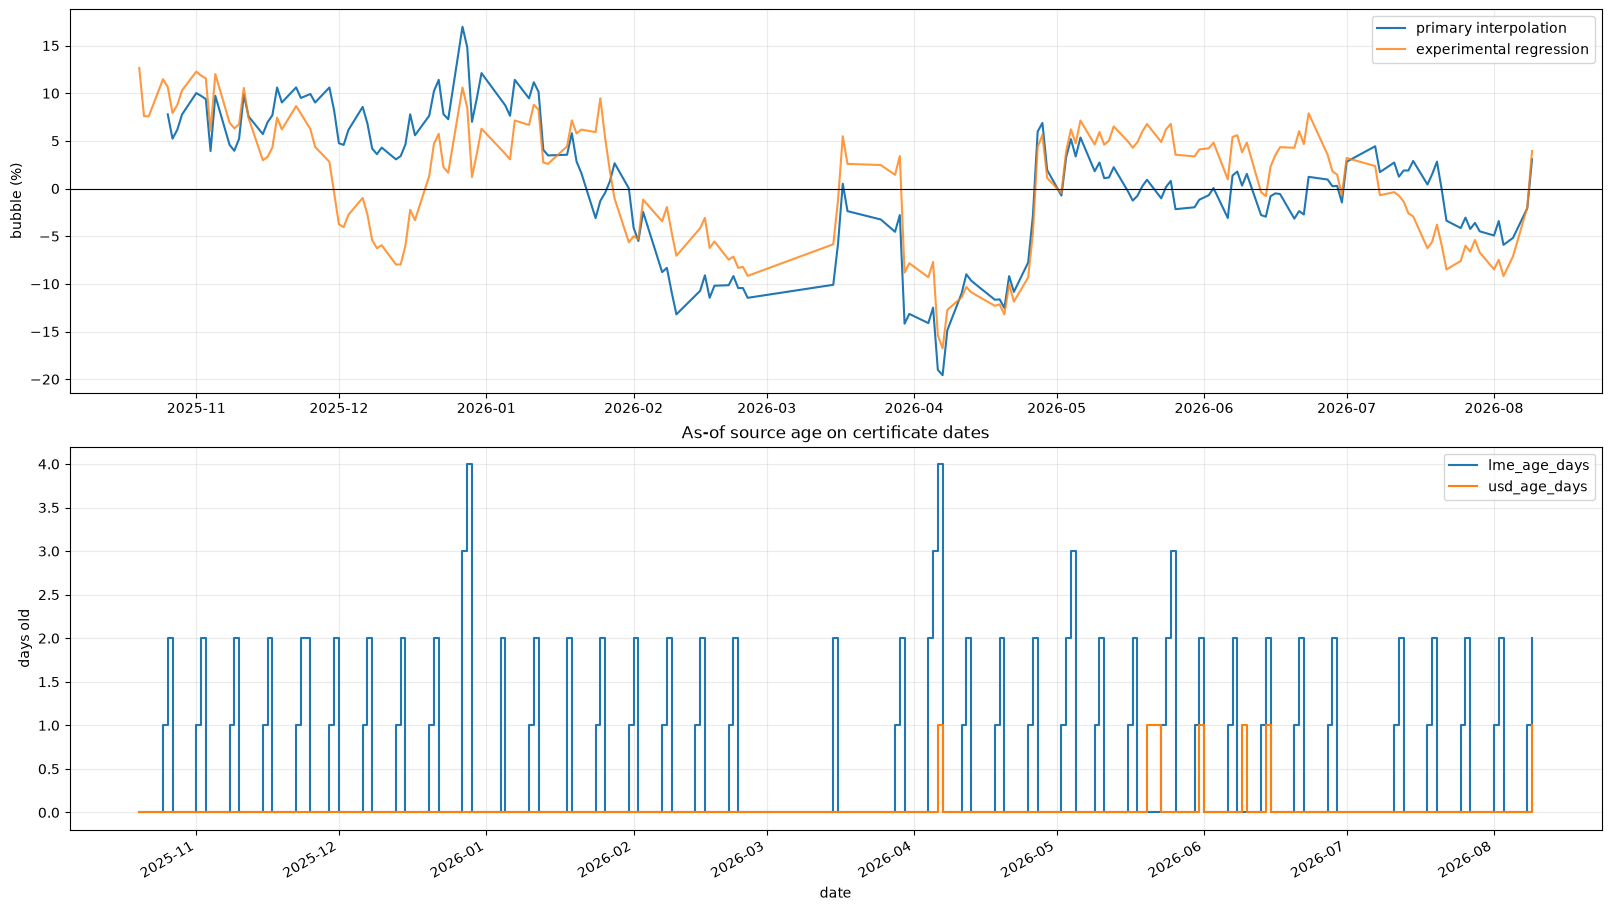

,count,mean,std,min,25%,50%,75%,max
lme_age_days,182.0,0.697802,0.941314,0.0,0.0,0.0,1.0,4.0
usd_age_days,182.0,0.032967,0.179043,0.0,0.0,0.0,0.0,1.0


In [6]:
display(regression_metrics.sort_values('timeseries_cv_rmse'))
fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)
axes[0].plot(primary['date'], primary['certificate_bubble_pct'], label='primary interpolation')
axes[0].plot(regression['date'], regression['certificate_bubble_pct'], label='experimental regression', alpha=.8)
axes[0].axhline(0, color='black', linewidth=.8); axes[0].legend(); axes[0].set_ylabel('bubble (%)'); axes[0].grid(alpha=.25)
age = certificate_direct[['date','lme_age_days','usd_age_days']].set_index('date')
age.plot(ax=axes[1], drawstyle='steps-post')
axes[1].set_title('As-of source age on certificate dates'); axes[1].set_ylabel('days old'); axes[1].grid(alpha=.25)
plt.show()
display(age.describe().T)